# Test H5 calibration workflow

## Example notebook

This notebook shows how to calibrate HDF5 FLIM datasets channel-by-channel,
save the results into per-data-key `calibration/<data_key>/` groups, and inspect
the stored calibration outputs such as `channels_time_skew`, `common_delay_in_ns`,
and `fit_error`.


In [14]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from brighteyes_flim import calibrate_h5_file, show_h5_structure_html


## Part 1 - Calibration setup and execution

This first section keeps the workflow focused on the inputs to `calibrate_h5_file(...)`
and the calibration run itself.


## Parameters and constants

Set the dataset keys, reference mode, input file paths, and channel-skew options here.
`CHANNEL_SKEW_TYPE_FIT_SOURCE` accepts `"ref"`, `"irf"`, `"data"`, or a NumPy array.
If `data` is present, extra groups use the selected reference channel from `data` by default.

In the usual workflow, `DATA_KEY` is enough: each data group is calibrated against the
matching dataset key in the reference file. You only need `reference_key` as an advanced
override when the reference file stores equivalent histograms under different dataset names,
or when you want to provide an explicit per-group mapping.


In [15]:
DATA_KEY = ("data", "data_channels_extra")
TAU_REF = 2.5  # in ns
# TAU_REF = None  # let the algorithm estimate the reference lifetime from the reference data
REFERENCE_TYPE = "ref"
FIT_MODE = "model_shift"
FIT_TYPE = "circular"
CHANNEL_SKEW_TYPE = "fit"
CHANNEL_SKEW_TYPE_FIT_SOURCE = "ref"
CHANNEL_SKEW_FIT_REFERENCE_CHANNEL = 12
CHANNEL_SKEW_FIT_UPSAMPLING = 10
CHANNEL_SKEW_FIT_APODIZE = False
# CHANNEL_SKEW_TYPE_FIT_SOURCE = np.array(custom_skew_bins, dtype=float)
# The custom array length must match the calibrated channel count of the target group.
OVERWRITE = True

FILE_REFERENCE = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/FLIMLABS_Yellow_slide_2_5ns-17-03-2026-16-18-22.h5"
FILE_DATA = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/01_Convallaria_DFD_40MHz-17-03-2026-16-59-41.h5"

# When DATA_KEY contains multiple HDF5 datasets, choose which one to inspect below.
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]


### A small note on defaults

This notebook now leaves `C_ref`, `irf_iterations`, and `regularization` out of the function
call on purpose. Their default values in `calibrate_h5_file(...)` already match the standard
DFD workflow, so keeping them implicit makes it easier to spot the parameters that are truly
being customized for a run.


### Run `calibrate_h5_file`

This cell performs the calibration and writes one `calibration/<data_key>/` group
per requested dataset key.

The stored names now distinguish clearly between:
- data used by the fit: `data_for_fit`, `ref_for_fit`, `irf_for_fit`
- fitted or realigned outputs: `data_fitted`, `ref_common_delay_realigned`, `irf_common_delay_realigned`
- scalar fit results: `fit_param_C`, `tau_ns`, `common_delay_in_ns`, `fit_error`

If `data` is present, non-`data` groups are anchored to the selected reference channel from `data` by default.


In [16]:
output_path = calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type=CHANNEL_SKEW_TYPE,
    channel_skew_type_fit_source=CHANNEL_SKEW_TYPE_FIT_SOURCE,
    channel_skew_fit_reference_channel=CHANNEL_SKEW_FIT_REFERENCE_CHANNEL,
    channel_skew_fit_upsampling=CHANNEL_SKEW_FIT_UPSAMPLING,
    channel_skew_fit_apodize=CHANNEL_SKEW_FIT_APODIZE,
    overwrite=OVERWRITE,
)

print(output_path)


Calibrating data keys:   0%|          | 0/2 [00:00<?, ?key/s]

Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

Calibrating data_channels_extra:   0%|          | 0/2 [00:00<?, ?ch/s]

/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/01_Convallaria_DFD_40MHz-17-03-2026-16-59-41_calib.h5


/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/h5_data_calibrator.py:1328: RuntimeWarning: Skipping calibration for data key 'data_channels_extra', channel 0: data histogram has a non-positive or non-finite sum
  ).calibrate()
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/alignment.py:207: RuntimeWarning: divide by zero encountered in divide
  resid = resid / sigma_array
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/h5_data_calibrator.py:1328: RuntimeWarning: Calibration fit failed for data key 'data_channels_extra', channel 1: Residuals are not finite in the initial point.
  ).calibrate()
/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/analysis/APR_lib.py:130: UserWarning: Could not determine RMS error between images with the normalized average intensities np.float64(3.5815482403654166) and np.float64(0.0). Either the reference or moving image may be empty.
  shift_vec[i, :], error[i, :], diffphase = 

## Part 2 - Visualization and debug

The cells below are for inspection, plotting, and debugging after calibration has finished.


In [17]:
def get_calibration_group(hf, data_key=INSPECT_DATA_KEY, calibration_key="calibration"):
    if isinstance(data_key, (list, tuple)):
        raise ValueError("Select a single DATA_KEY when inspecting one calibration group.")
    calibration_root = hf[calibration_key]
    if data_key not in calibration_root or not isinstance(calibration_root[data_key], h5py.Group):
        raise KeyError(
            f"Expected calibration group '{calibration_key}/{data_key}'. "
            f"Available entries: {list(calibration_root.keys())}"
        )
    return calibration_root[data_key]


def normalize_histogram(histogram):
    histogram = np.asarray(histogram, dtype=float)
    total = histogram.sum()
    return histogram if total <= 0 else histogram / total


### Inspect calibration results

The cells below read the calibrated HDF5 output without rerunning the fit.
This is useful when you want to verify:
- per-channel fit parameters and errors: `fit_param_C`, `fit_param_C_err`, `tau_ns`, `tau_err_ns`
- the fitted common delay in both bins and ns
- `channels_time_skew` and `channels_time_skew_err`
- `fit_error`, where lower is better

The per-channel dataset `channel_used_for_reference_in_time_skew` stores the mapped reference channel used during calibration. The single anchor used to estimate `channels_time_skew` is still stored in the group attributes.


In [18]:
with h5py.File(output_path, "r") as hf:
    calibration = get_calibration_group(hf)
    time_skew_source_name = str(
        calibration.attrs.get("channel_skew_type_fit_source", "not stored")
    )
    time_skew_reference_data_key = str(
        calibration.attrs.get("channel_skew_fit_reference_data_key", calibration.attrs["data_key"])
    )
    time_skew_reference_channel = int(
        calibration.attrs.get(
            "channel_skew_fit_reference_channel_resolved",
            CHANNEL_SKEW_FIT_REFERENCE_CHANNEL,
        )
    )
    time_skew_reference_position = calibration.attrs.get(
        "channel_skew_fit_reference_position",
        np.nan,
    )
    fit_error_metric = str(
        calibration.attrs.get("fit_error_metric", "not stored")
    )
    summary_df = pd.DataFrame(
        {
            "channel": calibration["channel_index"][()],
            "channel_used_for_reference_in_time_skew": calibration[
                "channel_used_for_reference_in_time_skew"
            ][()],
            "fit_param_C": calibration["fit_param_C"][()],
            "fit_param_C_err": calibration["fit_param_C_err"][()],
            "tau_ns": calibration["tau_ns"][()],
            "tau_err_ns": calibration["tau_err_ns"][()],
            "tau_ref_ns": calibration["tau_ref_ns"][()],
            "common_delay_in_bins": calibration["common_delay_in_bins"][()],
            "common_delay_err_in_bins": calibration["common_delay_err_in_bins"][()],
            "common_delay_in_ns": calibration["common_delay_in_ns"][()],
            "common_delay_err_in_ns": calibration["common_delay_err_in_ns"][()],
            "fit_error": calibration["fit_error"][()],
            "channels_time_skew": calibration["channels_time_skew"][()],
            "channels_time_skew_err": calibration["channels_time_skew_err"][()],
            "irf_type": calibration["irf_type"].asstr()[()],
        }
    )

display(summary_df.round(6))
print(f"channels_time_skew source: {time_skew_source_name}")
print(f"channels_time_skew reference data_key: {time_skew_reference_data_key}")
print(f"channels_time_skew resolved reference channel: {time_skew_reference_channel}")
print(f"channels_time_skew reference position: {time_skew_reference_position}")
print(f"fit_error metric: {fit_error_metric} (lower is better)")


,channel,channel_used_for_reference_in_time_skew,fit_param_C,fit_param_C_err,tau_ns,tau_err_ns,tau_ref_ns,common_delay_in_bins,common_delay_err_in_bins,common_delay_in_ns,common_delay_err_in_ns,fit_error,channels_time_skew,channels_time_skew_err,irf_type
0,0,0,0.050867,4.353342e+05,1.465084,0.046895,2.5,-5.053218,0.055595,-1.388247,0.015273,0.002742,0.3,0.015428,estimated_from_ref
1,1,1,0.533665,4.185738e+05,1.514509,0.047870,2.5,-5.000000,0.044644,-1.373626,0.012265,0.002845,-1.5,0.019199,estimated_from_ref
2,2,2,0.956897,3.826967e+05,1.432491,0.045451,2.5,-5.000000,0.040845,-1.373626,0.011221,0.002500,-1.6,0.015113,estimated_from_ref
3,3,3,0.836594,4.049654e+05,1.549800,0.047142,2.5,-5.027940,0.050521,-1.381302,0.013880,0.002591,0.3,0.016244,estimated_from_ref
4,4,4,1.351321,5.084879e+05,1.535075,0.049352,2.5,-5.000000,0.055269,-1.373626,0.015184,0.002562,-0.3,0.014274,estimated_from_ref
5,5,5,0.250842,2.337517e+05,1.515642,0.047748,2.5,-5.017987,0.057285,-1.378568,0.015738,0.002751,-0.1,0.015001,estimated_from_ref
6,6,6,9.466520,3.748161e+06,1.490570,0.049598,2.5,-5.045218,0.061798,-1.386049,0.016978,0.003020,-0.1,0.016345,estimated_from_ref
7,7,7,9.466849,2.550464e+06,1.501029,0.046759,2.5,-5.000000,0.049671,-1.373626,0.013646,0.002884,-0.5,0.015338,estimated_from_ref
8,8,8,1.473612,4.134617e+05,1.458697,0.045985,2.5,-5.000000,0.055970,-1.373626,0.015376,0.002440,-0.5,0.032835,estimated_from_ref
9,9,9,0.005196,2.847856e+05,1.566439,0.047587,2.5,-5.040870,0.058802,-1.384854,0.016154,0.002472,0.1,0.011988,estimated_from_ref


channels_time_skew source: ref
channels_time_skew reference data_key: data
channels_time_skew resolved reference channel: 12
channels_time_skew reference position: 12
fit_error metric: rmse_normalized_histograms (lower is better)


/tmp/ipykernel_2453147/351905405.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


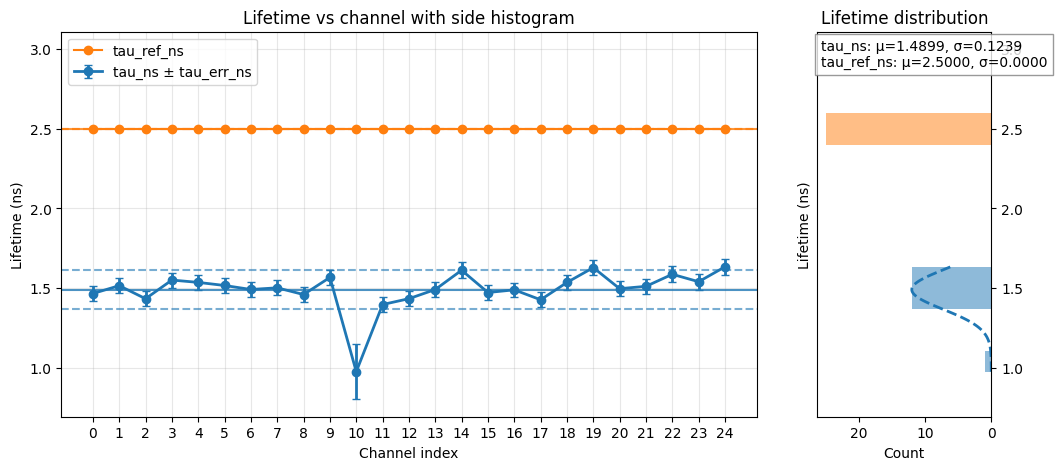

/tmp/ipykernel_2453147/351905405.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


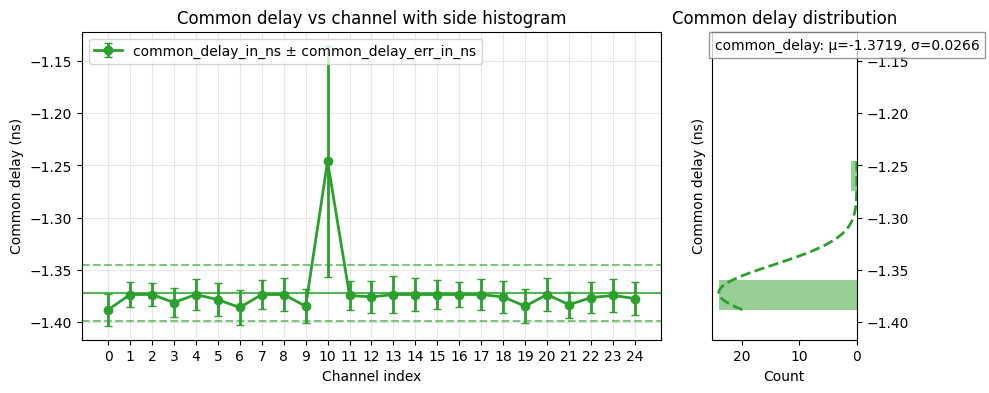

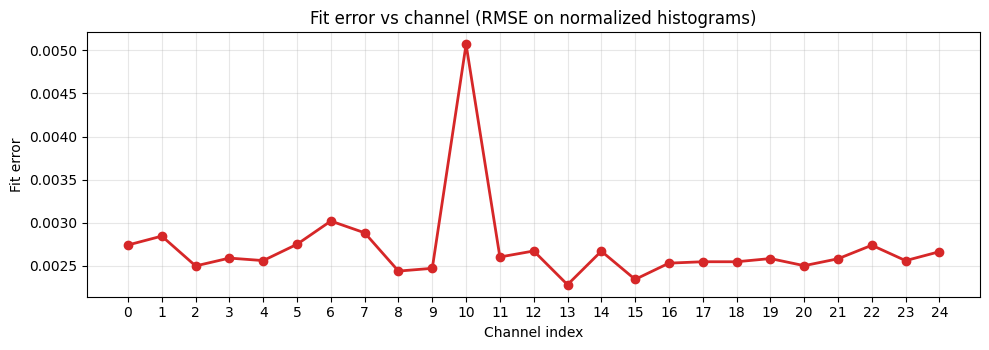

In [19]:
channels = summary_df["channel"].to_numpy()
tau = summary_df["tau_ns"]
tau_err = summary_df["tau_err_ns"]
tau_ref = summary_df["tau_ref_ns"]
common_delay = summary_df["common_delay_in_ns"]
common_delay_err = summary_df["common_delay_err_in_ns"]
fit_error = summary_df["fit_error"]

mean_tau = tau.mean()
std_tau = tau.std()
mean_tau_ref = tau_ref.mean()
std_tau_ref = tau_ref.std()
mean_common_delay = common_delay.mean()
std_common_delay = common_delay.std()

def add_gaussian_overlay(ax, values, color, bins, label):
    values = pd.Series(values).dropna()
    if values.empty:
        return
    std = values.std()
    if not np.isfinite(std) or std == 0:
        return
    y = np.linspace(values.min(), values.max(), 100)
    gaussian = np.exp(-0.5 * ((y - values.mean()) / std) ** 2) / (std * np.sqrt(2 * np.pi))
    hist_counts = np.histogram(values, bins=bins)[0]
    max_count = hist_counts.max() if hist_counts.size else 0
    if max_count > 0 and np.max(gaussian) > 0:
        ax.plot(
            gaussian * max_count / np.max(gaussian),
            y,
            color=color,
            linestyle="--",
            linewidth=2,
            label=label,
        )

fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[4, 1], wspace=0.14)
ax = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharey=ax)

ax.errorbar(
    channels,
    tau,
    yerr=tau_err,
    fmt="o-",
    color="tab:blue",
    linewidth=2,
    markersize=6,
    capsize=3,
    label="tau_ns ± tau_err_ns",
)
ax.plot(channels, tau_ref, "o-", label="tau_ref_ns", color="tab:orange")
ax.axhline(mean_tau, color="tab:blue", linestyle="-", alpha=0.8)
ax.axhline(mean_tau + std_tau, color="tab:blue", linestyle="--", alpha=0.6)
ax.axhline(mean_tau - std_tau, color="tab:blue", linestyle="--", alpha=0.6)
ax.axhline(mean_tau_ref, color="tab:orange", linestyle="-", alpha=0.8)
ax.axhline(mean_tau_ref + std_tau_ref, color="tab:orange", linestyle="--", alpha=0.6)
ax.axhline(mean_tau_ref - std_tau_ref, color="tab:orange", linestyle="--", alpha=0.6)

ax_hist.hist(tau.dropna(), bins=5, orientation="horizontal", color="tab:blue", alpha=0.5, label="tau_ns")
ax_hist.hist(tau_ref.dropna(), bins=5, orientation="horizontal", color="tab:orange", alpha=0.5, label="tau_ref_ns")
add_gaussian_overlay(ax_hist, tau, "tab:blue", 5, "tau_ns gaussian")
add_gaussian_overlay(ax_hist, tau_ref, "tab:orange", 5, "tau_ref_ns gaussian")

ax_hist.invert_xaxis()
ax_hist.tick_params(axis="y", left=False, labelleft=False, right=True, labelright=True)
ax_hist.set_xlabel("Count")
ax_hist.set_ylabel("Lifetime (ns)")
ax_hist.set_title("Lifetime distribution")

ax_hist.text(
    0.02,
    0.98,
    f"tau_ns: μ={mean_tau:.4f}, σ={std_tau:.4f}\ntau_ref_ns: μ={mean_tau_ref:.4f}, σ={std_tau_ref:.4f}",
    transform=ax_hist.transAxes,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
)

ax.set_xlabel("Channel index")
ax.set_ylabel("Lifetime (ns)")
ax.set_title("Lifetime vs channel with side histogram")
ax.set_xticks(channels)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

fig.tight_layout()
plt.show()

fig2 = plt.figure(figsize=(10, 4))
gs2 = fig2.add_gridspec(1, 2, width_ratios=[4, 1], wspace=0.14)
ax_delay = fig2.add_subplot(gs2[0])
ax_delay_hist = fig2.add_subplot(gs2[1], sharey=ax_delay)

ax_delay.errorbar(
    channels,
    common_delay,
    yerr=common_delay_err,
    fmt="o-",
    color="tab:green",
    linewidth=2,
    markersize=6,
    capsize=3,
    label="common_delay_in_ns ± common_delay_err_in_ns",
)
ax_delay.axhline(mean_common_delay, color="tab:green", linestyle="-", alpha=0.8)
ax_delay.axhline(mean_common_delay + std_common_delay, color="tab:green", linestyle="--", alpha=0.6)
ax_delay.axhline(mean_common_delay - std_common_delay, color="tab:green", linestyle="--", alpha=0.6)
ax_delay.set_xlabel("Channel index")
ax_delay.set_ylabel("Common delay (ns)")
ax_delay.set_title("Common delay vs channel with side histogram")
ax_delay.set_xticks(channels)
ax_delay.grid(True, alpha=0.3)
ax_delay.legend(loc="upper left")

ax_delay_hist.hist(common_delay.dropna(), bins=5, orientation="horizontal", color="tab:green", alpha=0.5)
add_gaussian_overlay(ax_delay_hist, common_delay, "tab:green", 5, "common_delay gaussian")

ax_delay_hist.invert_xaxis()
ax_delay_hist.tick_params(axis="y", left=False, labelleft=False, right=True, labelright=True)
ax_delay_hist.set_xlabel("Count")
ax_delay_hist.set_ylabel("Common delay (ns)")
ax_delay_hist.set_title("Common delay distribution")

ax_delay_hist.text(
    0.02,
    0.98,
    f"common_delay: μ={mean_common_delay:.4f}, σ={std_common_delay:.4f}",
    transform=ax_delay_hist.transAxes,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
)

fig2.tight_layout()
plt.show()

plt.figure(figsize=(10, 3.6))
plt.plot(channels, fit_error, "o-", color="tab:red", linewidth=2, markersize=6)
plt.xlabel("Channel index")
plt.ylabel("Fit error")
plt.title("Fit error vs channel (RMSE on normalized histograms)")
plt.xticks(channels)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Plot one calibrated channel from the stored `(t, ch)` datasets

This is a quick visual check of the traces written under `calibration/<data_key>/`.


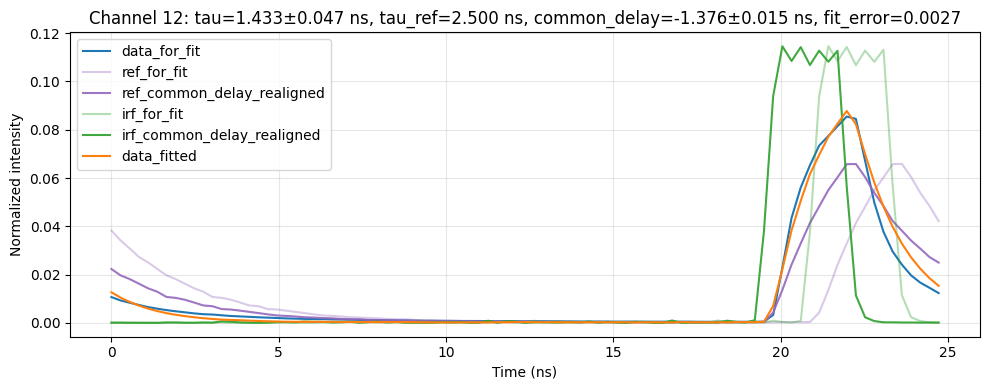

In [20]:
CHANNEL = 12

with h5py.File(output_path, "r") as hf:
    calibration = get_calibration_group(hf)
    calibrated_channels = calibration["channel_index"][()]
    column = int(np.where(calibrated_channels == CHANNEL)[0][0])

    data_for_fit = normalize_histogram(calibration["data_for_fit"][:, column])
    ref_for_fit = normalize_histogram(calibration["ref_for_fit"][:, column])
    ref_common_delay_realigned = normalize_histogram(
        calibration["ref_common_delay_realigned"][:, column]
    )
    irf_for_fit = normalize_histogram(calibration["irf_for_fit"][:, column])
    irf_common_delay_realigned = normalize_histogram(
        calibration["irf_common_delay_realigned"][:, column]
    )
    data_fitted = normalize_histogram(calibration["data_fitted"][:, column])
    period_ns = float(calibration.attrs["period_ns"])
    tau_ns = float(calibration["tau_ns"][column])
    tau_err_ns = float(calibration["tau_err_ns"][column])
    tau_ref_ns = float(calibration["tau_ref_ns"][column])
    common_delay_ns = float(calibration["common_delay_in_ns"][column])
    common_delay_err_ns = float(calibration["common_delay_err_in_ns"][column])
    fit_error = float(calibration["fit_error"][column])

t_ns = np.arange(data_for_fit.size, dtype=float) * period_ns / data_for_fit.size

plt.figure(figsize=(10, 4))
plt.plot(t_ns, data_for_fit, label="data_for_fit", color="tab:blue")
plt.plot(t_ns, ref_for_fit, label="ref_for_fit", color="tab:purple", alpha=0.35)
plt.plot(
    t_ns,
    ref_common_delay_realigned,
    label="ref_common_delay_realigned",
    color="tab:purple",
    alpha=0.9,
)
plt.plot(t_ns, irf_for_fit, label="irf_for_fit", color="tab:green", alpha=0.35)
plt.plot(
    t_ns,
    irf_common_delay_realigned,
    label="irf_common_delay_realigned",
    color="tab:green",
    alpha=0.9,
)
plt.plot(t_ns, data_fitted, label="data_fitted", color="tab:orange")
plt.xlabel("Time (ns)")
plt.ylabel("Normalized intensity")
plt.title(
    f"Channel {CHANNEL}: tau={tau_ns:.3f}±{tau_err_ns:.3f} ns, "
    f"tau_ref={tau_ref_ns:.3f} ns, common_delay={common_delay_ns:.3f}±{common_delay_err_ns:.3f} ns, "
    f"fit_error={fit_error:.4f}"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Direct IRF workflow

If the second file is already an IRF measurement, switch to `reference_type="irf"`.


In [21]:
# Example:
# f_irf = "/path/to/direct_irf_measurement.h5"
# output_path_irf = calibrate_h5_file(
#     FILE_DATA,
#     f_irf,
#     data_key="data",
#     reference_type="irf",
#     fit_mode="model_shift",
#     overwrite=True,
# )
# print(output_path_irf)


In [22]:
with h5py.File(output_path, "r") as hf:
    calibration = get_calibration_group(hf)
    print("selected DATA_KEY:", INSPECT_DATA_KEY)
    print("group path:", calibration.name)
    print("group keys:", list(calibration.keys()))
    print("data_for_fit shape:", calibration["data_for_fit"].shape)
    print("irf_common_delay_realigned shape:", calibration["irf_common_delay_realigned"].shape)
    if "ref_common_delay_realigned" in calibration:
        print("ref_common_delay_realigned shape:", calibration["ref_common_delay_realigned"].shape)
    print("fit_param_C_err shape:", calibration["fit_param_C_err"].shape)
    print("tau_err_ns shape:", calibration["tau_err_ns"].shape)
    print("common_delay_err_in_ns shape:", calibration["common_delay_err_in_ns"].shape)
    print("fit_error shape:", calibration["fit_error"].shape)
    print("channels_time_skew shape:", calibration["channels_time_skew"].shape)
    print("channels_time_skew_err shape:", calibration["channels_time_skew_err"].shape)
    print("fit_error metric:", calibration.attrs.get("fit_error_metric", "not stored"))
    print("channel_index:", calibration["channel_index"][()])


selected DATA_KEY: data
group path: /calibration/data
group keys: ['channel_index', 'channel_used_for_reference_in_time_skew', 'channels_time_skew', 'channels_time_skew_err', 'common_delay_err_in_bins', 'common_delay_err_in_ns', 'common_delay_in_bins', 'common_delay_in_ns', 'data_fitted', 'data_for_fit', 'fit_error', 'fit_param_C', 'fit_param_C_err', 'irf_common_delay_realigned', 'irf_for_fit', 'irf_type', 'ref_common_delay_realigned', 'ref_for_fit', 'tau_err_ns', 'tau_ns', 'tau_ref_ns']
data_for_fit shape: (91, 25)
irf_common_delay_realigned shape: (91, 25)
ref_common_delay_realigned shape: (91, 25)
fit_param_C_err shape: (25,)
tau_err_ns shape: (25,)
common_delay_err_in_ns shape: (25,)
fit_error shape: (25,)
channels_time_skew shape: (25,)
channels_time_skew_err shape: (25,)
fit_error metric: rmse_normalized_histograms
channel_index: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]


In [23]:
with h5py.File(output_path, "r") as hf:
    calibration = get_calibration_group(hf)
    print("fit_param_C:", calibration["fit_param_C"][:])
    print("fit_param_C_err:", calibration["fit_param_C_err"][:])
    print("tau_ns:", calibration["tau_ns"][:])
    print("tau_err_ns:", calibration["tau_err_ns"][:])
    print("tau_ref_ns:", calibration["tau_ref_ns"][:])
    print("common_delay_in_ns:", calibration["common_delay_in_ns"][:])
    print("common_delay_err_in_ns:", calibration["common_delay_err_in_ns"][:])
    print("fit_error:", calibration["fit_error"][:])
    print("channels_time_skew:", calibration["channels_time_skew"][:])
    print("channels_time_skew_err:", calibration["channels_time_skew_err"][:])
    print(
        "channel_used_for_reference_in_time_skew:",
        calibration["channel_used_for_reference_in_time_skew"][:],
    )
    print("channels_time_skew source:", calibration.attrs.get("channel_skew_type_fit_source", "not stored"))
    print(
        "channel_skew_fit_reference_channel (requested):",
        calibration.attrs.get("channel_skew_fit_reference_channel", "not stored"),
    )
    print(
        "channels_time_skew reference data_key:",
        calibration.attrs.get("channel_skew_fit_reference_data_key"),
    )
    print(
        "channels_time_skew resolved reference channel:",
        calibration.attrs.get("channel_skew_fit_reference_channel_resolved"),
    )
    print(
        "channels_time_skew reference position:",
        calibration.attrs.get("channel_skew_fit_reference_position"),
    )
    print("channel_skew_fit_upsampling:", calibration.attrs.get("channel_skew_fit_upsampling", "not stored"))
    print("channel_skew_fit_apodize:", calibration.attrs.get("channel_skew_fit_apodize", "not stored"))
    print("fit_error_metric:", calibration.attrs.get("fit_error_metric", "not stored"))
    print("group attrs:", list(calibration.attrs.keys()))


fit_param_C: [5.08672886e-02 5.33664639e-01 9.56896961e-01 8.36593601e-01
 1.35132101e+00 2.50841955e-01 9.46651988e+00 9.46684911e+00
 1.47361191e+00 5.19574325e-03 3.25176423e-01 2.16651785e+00
 2.01265492e+00 1.70425564e+00 3.80345090e+00 2.40904773e+00
 5.55845075e-01 1.40671352e+00 8.42069139e+00 5.50990288e-02
 9.79308756e-01 2.37771862e-02 1.33490175e+00 8.88066953e-01
 1.70320695e+00]
fit_param_C_err: [ 435334.22934083  418573.77533273  382696.71136318  404965.36283478
  508487.88504769  233751.70295692 3748161.05850479 2550463.77082951
  413461.74998434  284785.55645033 1528636.30634169  667192.91417958
  462698.61917379  490929.56582031 1388010.15290201  761928.35295644
  414196.56877763  490740.34106349 3714889.27764501  305061.0774286
  498302.46372698  315386.64662336  520971.94083268  251481.85790387
  695071.09569049]
tau_ns: [1.4650843  1.5145089  1.43249108 1.54979997 1.53507534 1.51564233
 1.49056986 1.50102943 1.45869708 1.56643945 0.97425884 1.396029
 1.4327964  1.4

In [24]:
# Show the full HDF5 structure of the calibrated output file
show_h5_structure_html(output_path);


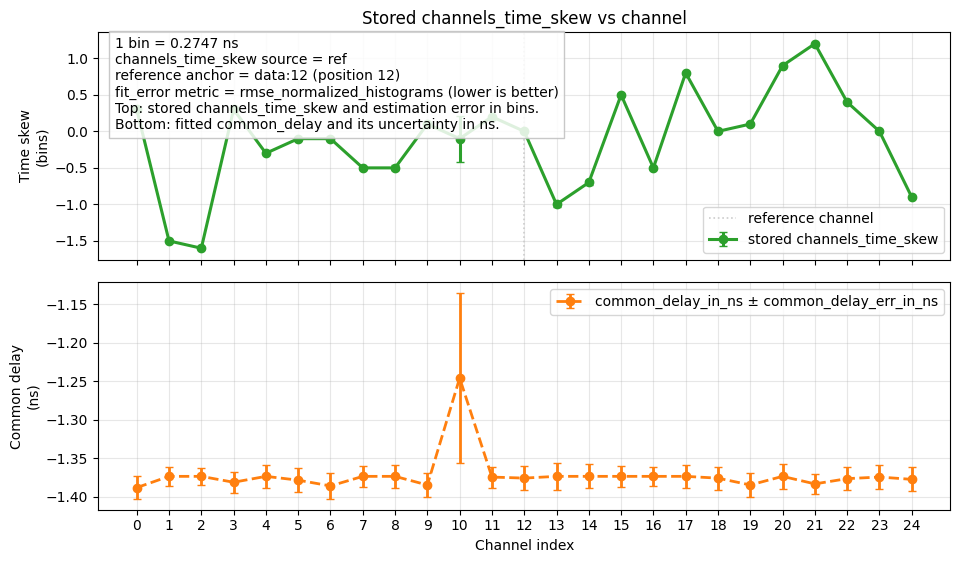

In [25]:
with h5py.File(output_path, "r") as hf:
    calibration = get_calibration_group(hf)
    dt_ns = float(calibration.attrs["dt_ns"])
    current_data_key = str(calibration.attrs["data_key"])
    time_skew_source_name = str(
        calibration.attrs.get("channel_skew_type_fit_source", "not stored")
    )
    ref_data_key = str(calibration.attrs.get("channel_skew_fit_reference_data_key", current_data_key))
    ref_channel = int(
        calibration.attrs.get(
            "channel_skew_fit_reference_channel_resolved",
            CHANNEL_SKEW_FIT_REFERENCE_CHANNEL,
        )
    )
    ref_position = calibration.attrs.get("channel_skew_fit_reference_position", np.nan)
    fit_error_metric = str(calibration.attrs.get("fit_error_metric", "not stored"))

shift_channels = summary_df["channel"].to_numpy()
temporal_shift_bins = summary_df["channels_time_skew"].to_numpy()
temporal_shift_err_bins = summary_df["channels_time_skew_err"].to_numpy()
common_delay_ns = summary_df["common_delay_in_ns"].to_numpy()
common_delay_err_ns = summary_df["common_delay_err_in_ns"].to_numpy()

fig, (ax_shift, ax_delay) = plt.subplots(
    2,
    1,
    figsize=(11, 6.2),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.1},
)

ax_shift.errorbar(
    shift_channels,
    temporal_shift_bins,
    yerr=temporal_shift_err_bins,
    fmt="o-",
    color="tab:green",
    linewidth=2.2,
    markersize=6,
    capsize=3,
    label="stored channels_time_skew",
)
if ref_data_key == current_data_key and ref_channel in set(shift_channels.tolist()):
    ax_shift.axvline(ref_channel, color="0.8", linestyle=":", linewidth=1.2, label="reference channel")
ax_shift.set_ylabel("Time skew\n(bins)")
ax_shift.set_title("Stored channels_time_skew vs channel")
ax_shift.grid(True, alpha=0.3)
ax_shift.legend(loc="best")

ax_delay.errorbar(
    shift_channels,
    common_delay_ns,
    yerr=common_delay_err_ns,
    fmt="o--",
    color="tab:orange",
    linewidth=2.0,
    markersize=6,
    capsize=3,
    label="common_delay_in_ns ± common_delay_err_in_ns",
)
ax_delay.set_xlabel("Channel index")
ax_delay.set_ylabel("Common delay\n(ns)")
ax_delay.set_xticks(shift_channels)
ax_delay.grid(True, alpha=0.3)
ax_delay.legend(loc="best")

ax_shift.text(
    0.02,
    0.98,
    (
        f"1 bin = {dt_ns:.4f} ns\n"
        f"channels_time_skew source = {time_skew_source_name}\n"
        f"reference anchor = {ref_data_key}:{ref_channel} (position {ref_position})\n"
        f"fit_error metric = {fit_error_metric} (lower is better)\n"
        "Top: stored channels_time_skew and estimation error in bins.\n"
        "Bottom: fitted common_delay and its uncertainty in ns."
    ),
    transform=ax_shift.transAxes,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="0.75"),
)

plt.show()


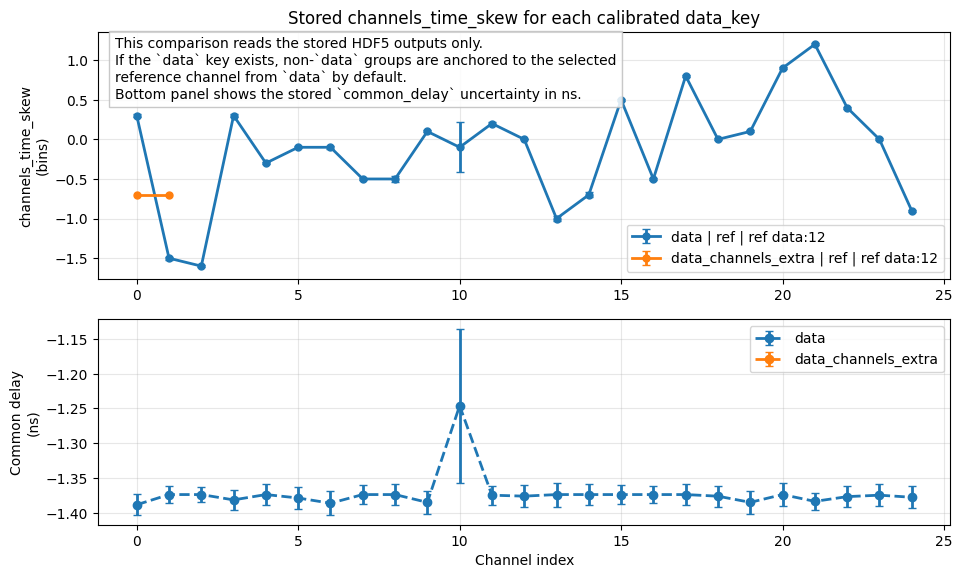

In [26]:
data_keys = [DATA_KEY] if isinstance(DATA_KEY, str) else list(DATA_KEY)

fig, (ax_shift, ax_delay) = plt.subplots(
    2,
    1,
    figsize=(11, 6.4),
    sharex=False,
    gridspec_kw={"height_ratios": [1.2, 1], "hspace": 0.18},
)

with h5py.File(output_path, "r") as hf:
    for data_key in data_keys:
        calibration = get_calibration_group(hf, data_key=data_key)
        group_df = pd.DataFrame(
            {
                "channel": calibration["channel_index"][()],
                "channels_time_skew": calibration["channels_time_skew"][()],
                "channels_time_skew_err": calibration["channels_time_skew_err"][()],
                "common_delay_in_ns": calibration["common_delay_in_ns"][()],
                "common_delay_err_in_ns": calibration["common_delay_err_in_ns"][()],
            }
        )
        ref_data_key = str(calibration.attrs.get("channel_skew_fit_reference_data_key", data_key))
        ref_channel = int(
            calibration.attrs.get(
                "channel_skew_fit_reference_channel_resolved",
                CHANNEL_SKEW_FIT_REFERENCE_CHANNEL,
            )
        )
        source_name = str(calibration.attrs.get("channel_skew_type_fit_source", "not stored"))

        ax_shift.errorbar(
            group_df["channel"],
            group_df["channels_time_skew"],
            yerr=group_df["channels_time_skew_err"],
            fmt="o-",
            linewidth=2,
            markersize=5,
            capsize=3,
            label=f"{data_key} | {source_name} | ref {ref_data_key}:{ref_channel}",
        )

        ax_delay.errorbar(
            group_df["channel"],
            group_df["common_delay_in_ns"],
            yerr=group_df["common_delay_err_in_ns"],
            fmt="o--",
            linewidth=2.0,
            markersize=6,
            capsize=3,
            label=data_key,
        )

ax_shift.set_ylabel("channels_time_skew\n(bins)")
ax_shift.set_title("Stored channels_time_skew for each calibrated data_key")
ax_shift.grid(True, alpha=0.3)
ax_shift.legend(loc="best")

ax_delay.set_xlabel("Channel index")
ax_delay.set_ylabel("Common delay\n(ns)")
ax_delay.grid(True, alpha=0.3)
ax_delay.legend(loc="best")

ax_shift.text(
    0.02,
    0.98,
    (
        "This comparison reads the stored HDF5 outputs only.\n"
        "If the `data` key exists, non-`data` groups are anchored to the selected\n"
        "reference channel from `data` by default.\n"
        "Bottom panel shows the stored `common_delay` uncertainty in ns."
    ),
    transform=ax_shift.transAxes,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="0.75"),
)

plt.show()
